In [1]:
import tensorflow as tf # tested with 1.14.0
from keras.models import Sequential # feed forward training - each node is linked with it`s predecesor
from keras.layers import Dense # nodes are fully connected across the entire NN
import numpy
import pandas as pd
#from google.colab import files
#uploaded=files.upload()

In [2]:
df = pd.read_csv("/kaggle/input/datasets/gimnakatugampala/diabetes/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [3]:
model=Sequential() # commences with creating the structure of the NN, layers are connected from left to right

In [4]:
model.add(Dense(12,input_dim=8,activation='relu'))
model.add(Dense(20,activation='relu')) # hidden layer -01
model.add(Dense(20,activation='relu')) # hidden layer -02
model.add(Dense(22,activation='relu')) # hidden layer -03
model.add(Dense(1,activation='sigmoid')) # output layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-13 06:23:08.516759: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


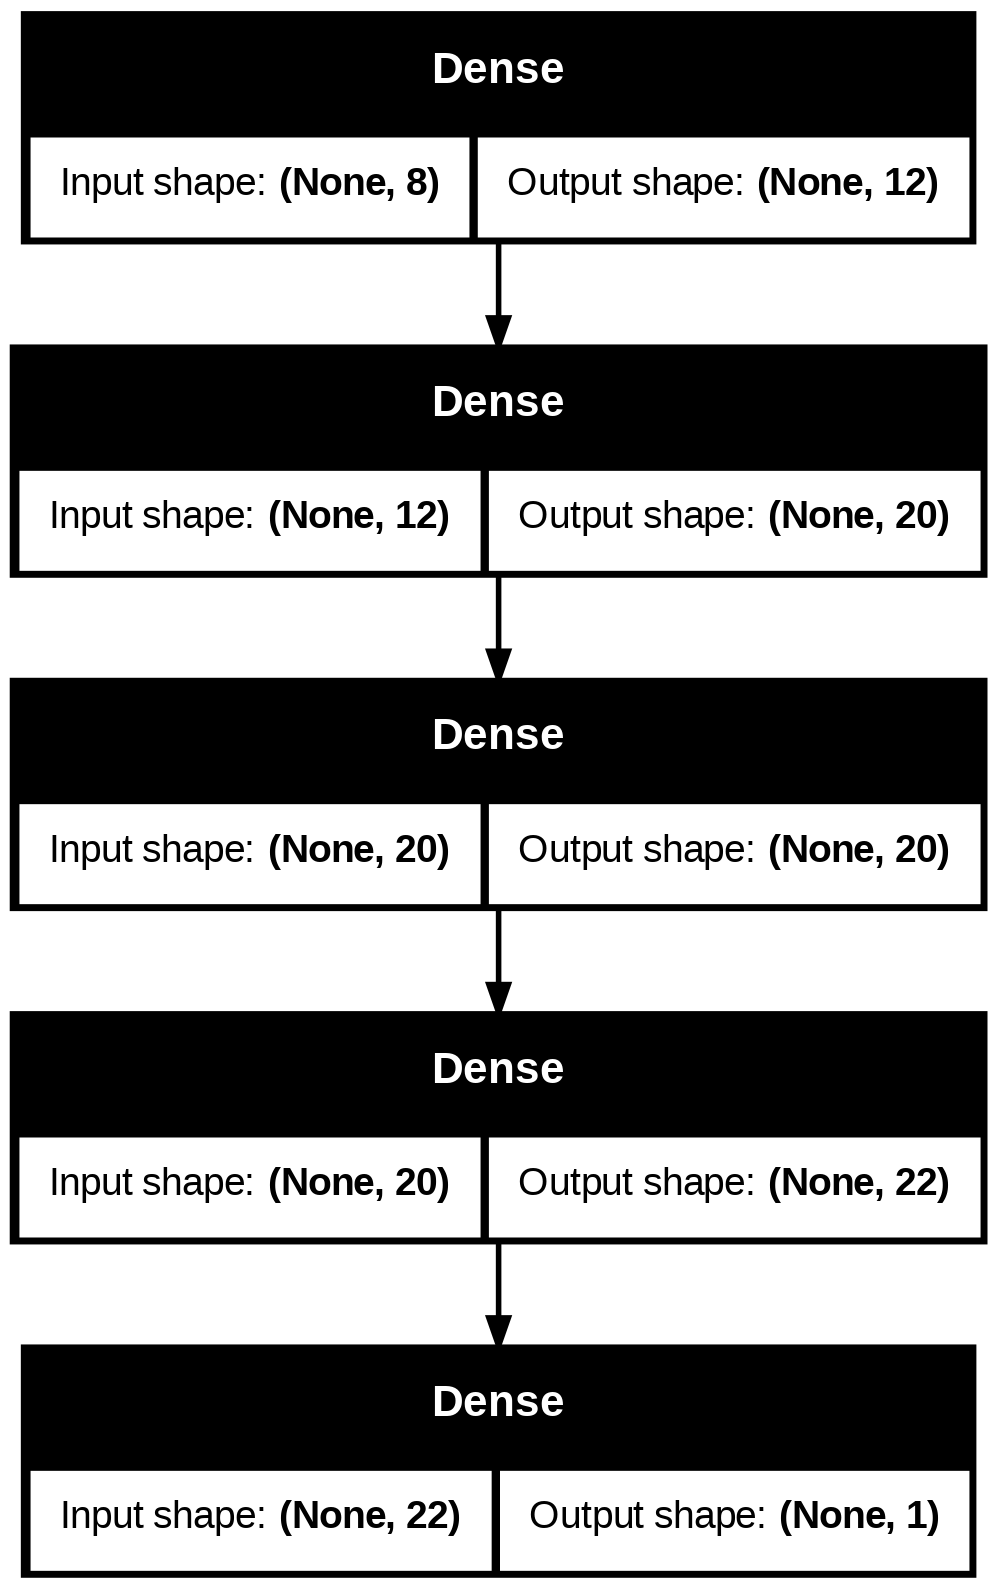

In [5]:
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=False)

In [6]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy']) # configuring your back-propergation execution

In [7]:
inputs = df.drop(['Outcome'],axis='columns') # independant dataset, excluding the dependent attibute
inputs

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72.0,35,169.5,33.6,0.627,50
1,1,85,66.0,29,102.5,26.6,0.351,31
2,8,183,64.0,32,169.5,23.3,0.672,32
3,1,89,66.0,23,94.0,28.1,0.167,21
4,0,137,40.0,35,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76.0,48,180.0,32.9,0.171,63
764,2,122,70.0,27,102.5,36.8,0.340,27
765,5,121,72.0,23,112.0,26.2,0.245,30
766,1,126,60.0,32,169.5,30.1,0.349,47


In [8]:
target=df.Outcome # dependant attribute

In [9]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(inputs,target,test_size=0.2) # 20% is allocated for the testing

In [11]:
model.fit(X_train,y_train,epochs=100,batch_size=10)

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6873 - loss: 0.7455
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7362 - loss: 0.5501
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7704 - loss: 0.5017
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7655 - loss: 0.4987
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8160 - loss: 0.4595
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8046 - loss: 0.4640
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7997 - loss: 0.4492
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8160 - loss: 0.5463
Epoch 9/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7964 - loss: 0.4550
Epoch 10/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7964 - loss: 0.4980
Epoch 11/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7915 - loss: 0.4530
Epoch 12/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

In [12]:
scores=model.evaluate(X_test,y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7792 - loss: 0.5104  


In [13]:
print(model.metrics_names[1],scores[1]*100)

compile_metrics 77.92207598686218


In [14]:
print(model.metrics_names[0],scores[0]*100)

loss 51.042866706848145


In [15]:
model.predict(X_test[11:22])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


array([[0.7918265 ],
       [0.7281005 ],
       [0.30186802],
       [0.01312928],
       [0.6758519 ],
       [0.04821474],
       [0.68621653],
       [0.5513128 ],
       [0.81297684],
       [0.0575004 ],
       [0.02920879]], dtype=float32)